<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

####  Análisis y Procesamiento de Señales - 1C 2026
# Trabajo Práctico Nº 4: Primeras nociones de estimación espectral
#### Mariano Gonzalez


Comenzaremos con la generación de la siguiente señal:
\begin{equation}x(k)=a0⋅sen(Ω1⋅n)+na(n)\end{equation}

siendo
\begin{equation}
a0=2\end{equation}

\begin{equation}Ω1=Ω0+fr⋅2πN\end{equation}

\begin{equation}Ω0=π2
\end{equation}

siendo la variable aleatoria definida por la siguiente distribución de probabilidad

\begin{equation}fr∼U(−2,2)\end{equation}


\begin{equation}na∼N(0,σ^2)\end{equation}

Diseñe los siguientes estimadores,  de amplitud $a1$


\begin{equation}a^i1=|Xiw(Ω0)|=|F{x(n)⋅wi(n)}|\end{equation}


 y de frecuencia $Ω1$


\begin{equation}Ω^i1=arg maxf{|Xiw(Ω)|}\end{equation}

para cada una de las ventanas:

- rectangular (sin ventana), 
- flattop 
- blackmanharris
- otra que elija de scipy.signal.windows
  
Y siguiendo las siguientes consignas para su experimentación:

Considere 200 realizaciones (muestras tomadas de $fr$) de 1000 muestras para cada experimento.

Parametrice para SNR's de 3 y 10 db (Ayuda: calibre $a1$ para que la potencia de la senoidal sea 1 W).


## 1) 
#### Realizar una tabla por cada SNR, que describa el sesgo y la varianza de cada estimador para cada ventana analizada. Recuerde incluir las ventanas rectangular (sin ventana), flattop y blackmanharris y otras que considere. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft
import scipy.signal as sig 

# Parámetros
fs = 1000
R = 200
N = fs
df = fs / N
ts = 1 / fs
eps = 1e-12
a0 = np.sqrt(2)
p_senal = a0**2 / 2   # = 1W 
w0 = int(N/4) #omega_0

# fr ~ U(-2, 2): columna (R,1) → matriz (R, N)
fr = np.random.uniform(low=-2, high=2, size=(R, 1)) #generador de jitter en forma de vector columna (Rx1)

# n: fila (1, N) → matriz (R, N)
n = np.arange(N).reshape(1, N)*ts # genero el vector de tiempo de forma vector fila (1xN)

w1 = (w0 + fr)*df # omega_1 - multiplico por df para que quede en hertz


### Experiencia para 10dB
A modo de ejemplo veremos el grafico de una FFT con ventaneo rectangular y luego las demas con zoom entre 247 y 253 para observar el desparramo que produce el jitter de Fr(entre -2 y 2), va variacion va desde 248 y 252, pero le doy un holgura mas por que sigue desparrando debido a la resolucion espectral y a la estructura del lobulo principal y secundario de cada ventana

In [20]:
# experiencia con 10dB
SNR_db = 10
p_ruido = 10**(-SNR_db/10)
sigma = np.sqrt(p_senal*p_ruido)
na = np.random.normal(0,sigma,(R, N))
#todas las variables que terminen con 10 significa que son con 10dB, las que terminen en 3 significa que son de 3dB

argumento = ((2*np.pi)*w1)*(n) # no olvidar que es (2pi*f)* (n*ts)
#notar que no genere matrices para el broadcasting, sino que uso la pripiedad de multiplicacion de matriz:
#Rx1*1xN= RxN, entonces el argumento se convierte en una matriz de RxN
seno_10 = (a0 * np.sin(argumento) + na)

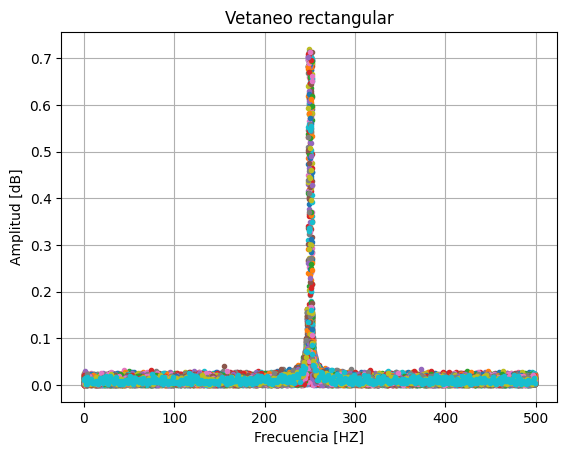

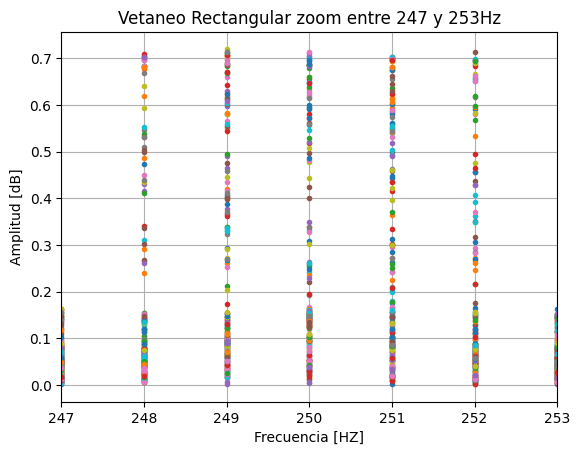

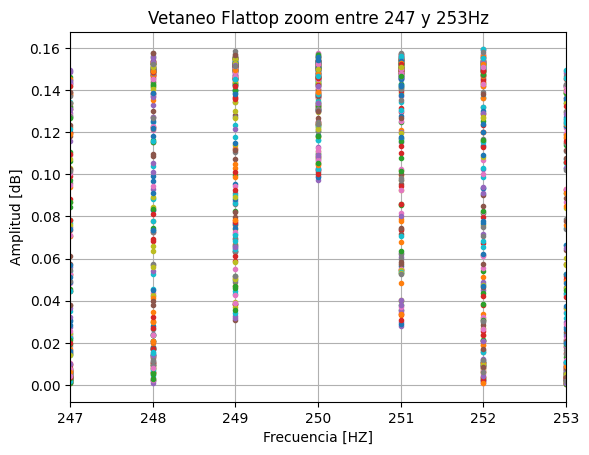

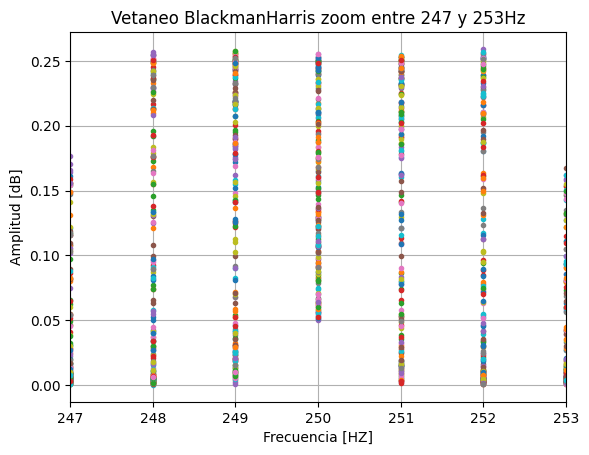

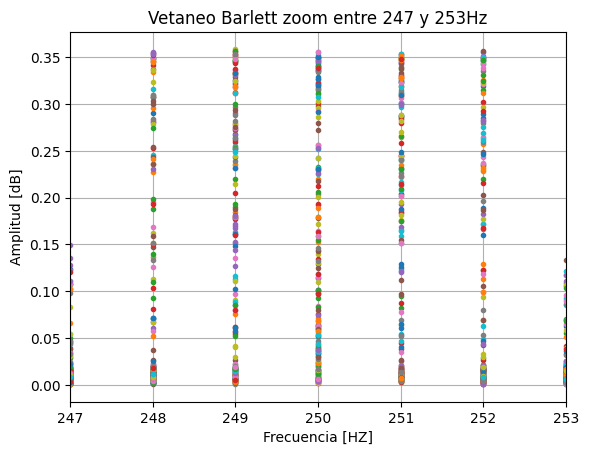

Estimador de amplitud para 10 dB
Ventana                     Sesgo     Varianza
----------------------------------------------
Rectangular              1.175471     0.049523
Flattop                  1.277206     0.000264
BlackmanHarris           1.258295     0.004442
Barlett                  1.272359     0.015792
**********************************************
**********************************************
Estimador de frecuencia para 10 dB
Ventana                     Sesgo     Varianza
----------------------------------------------
Rectangular              0.040000     1.638400
Flattop                  0.030000     1.619100
BlackmanHarris           0.030000     1.639100
Barlett                  0.035000     1.623775


In [29]:
##ventaneo
#para la rectangular no hace falta ventana explicita, ya que por el mero hecho de poner un N ya estamos ventaneando implicitamente
a1_flat_10 = seno_10*(sig.windows.flattop(N))
a1_black_10 = seno_10*(sig.windows.blackmanharris(N))
a1_bart_10=seno_10*(sig.windows.bartlett(N))

##transformada de Fourier
XX_rect10 = fft(seno_10,n=N,axis=1)* ts
abs_XX_rect10 = np.abs(XX_rect10)

XX_flat10 = fft(a1_flat_10,n=N,axis=1)*ts
abs_XX_flat10 = np.abs(XX_flat10)

ZXX_flat10 = fft(a1_flat_10,n=N*9,axis=1)*(1/(N))
Zabs_XX_flat10 = np.abs(ZXX_flat10)

XX_black10 = fft(a1_black_10,n=N,axis=1)*ts
abs_XX_black10 = np.abs(XX_black10)

XX_bart10 = fft(a1_bart_10,n=N,axis=1)*ts
abs_XX_bart10 = np.abs(XX_bart10)

#valores en logaritmo
abs_XX_rect10_db = 10*np.log10(abs_XX_rect10 + eps)
abs_XX_flat10_db = 10*np.log10(abs_XX_flat10 + eps)
Zabs_XX_flat10_db = 10*np.log10(Zabs_XX_flat10 + eps)
abs_XX_black10_db = 10*np.log10(abs_XX_black10 + eps)
abs_XX_bart10_db = 10*np.log10(abs_XX_bart10 + eps)



eje_x  = np.fft.fftfreq(N, ts)[:N//2]    # 0 a 499 Hz

plt.figure(1)            
plt.plot(eje_x, abs_XX_rect10[:, :N//2].T, marker='.', linestyle='None')
plt.title("Vetaneo rectangular")
plt.xlabel("Frecuencia [HZ]")
plt.ylabel("Amplitud [dB]")
#plt.ylim(,0.7)  # ← acá el zoom
#plt.xlim(247,253)  # ← acá el zoom
plt.grid(True)
plt.show()

plt.figure(1)            
plt.plot(eje_x, abs_XX_rect10[:, :N//2].T, marker='.', linestyle='None')
plt.title("Vetaneo Rectangular zoom entre 247 y 253Hz")
plt.xlabel("Frecuencia [HZ]")
plt.ylabel("Amplitud [dB]")
plt.xlim(247,253)  # zoom
plt.grid(True)
plt.show()

plt.figure(2)
plt.plot(eje_x, abs_XX_flat10[:, :N//2].T, marker='.', linestyle='None')
plt.title("Vetaneo Flattop zoom entre 247 y 253Hz")
plt.xlabel("Frecuencia [HZ]")
plt.ylabel("Amplitud [dB]")
plt.xlim(247,253)  # zoom
plt.grid(True)
plt.show()

plt.figure(3)
plt.plot(eje_x, abs_XX_black10[:, :N//2].T,marker='.', linestyle='None')
plt.title("Vetaneo BlackmanHarris zoom entre 247 y 253Hz")
plt.xlabel("Frecuencia [HZ]")
plt.ylabel("Amplitud [dB]")
plt.xlim(247,253)  # zoom
plt.grid(True)
plt.show()

plt.figure(4)
plt.plot(eje_x, abs_XX_bart10[:, :N//2].T,marker='.', linestyle='None')
plt.title("Vetaneo Barlett zoom entre 247 y 253Hz")
plt.xlabel("Frecuencia [HZ]")
plt.ylabel("Amplitud [dB]")
plt.xlim(247,253)  # zoom
plt.grid(True)
plt.show()

#Estimador amplitud
#estimador en n/4, es decir que saco una "feta" de la matriz RxN
a1_rect_est10 = abs_XX_rect10[:,N//4]
a1_flat_est10 = abs_XX_flat10[:,N//4]
Za1_flat_est10 = Zabs_XX_flat10[:,N//4]
a1_black_est10 = abs_XX_black10[:,N//4]
a1_bart_est10 = abs_XX_bart10[:,N//4]

#sesgo de amplitud
sesgo_rect_10 = np.abs(np.mean(a1_rect_est10 - a0))
sesgo_flat_10 = np.abs(np.mean(a1_flat_est10 - a0))
Zsesgo_flat_10 = np.abs(np.mean(Za1_flat_est10 - a0))
sesgo_black_10 = np.abs(np.mean(a1_black_est10 - a0))
sesgo_bart_10 = np.abs(np.mean(a1_bart_est10 - a0))

#varianza de estimador de amplitud
var_rect_10 = np.var(a1_rect_est10)
var_flat_10 = np.var(a1_flat_est10)
Zvar_flat_10 = np.var(Za1_flat_est10)
var_black_10 = np.var(a1_black_est10)
var_bart_10 = np.var(a1_bart_est10)

# Estimador frecuencia
# Indice de la realización con mayor potencia
w1_rect10 = np.argmax(abs_XX_rect10[:, :N//2], axis=1)   
w1_flat10 = np.argmax(abs_XX_flat10[:, :N//2], axis=1)
Zw1_flat10 = np.argmax(Zabs_XX_flat10[:, :N//2], axis=1)
w1_black10 = np.argmax(abs_XX_black10[:, :N//2], axis=1)
w1_bart10 = np.argmax(abs_XX_bart10[:, :N//2], axis=1)

sesgofr_rect_10 = np.abs(np.mean(w1_rect10 - w0 ))
sesgofr_flat_10 = np.abs(np.mean(w1_flat10 - w0))
Zsesgofr_flat_10 = np.abs(np.mean(Zw1_flat10 - w0))
sesgofr_black_10 = np.abs(np.mean(w1_black10 - w0))
sesgofr_bart_10 = np.abs(np.mean(w1_bart10 - w0))

varfr_rect_10 = np.var(w1_rect10)
varfr_flat_10 = np.var(w1_flat10)
Zvarfr_flat_10 = np.var(Zw1_flat10)
varfr_black_10 = np.var(w1_black10)
varfr_bart_10 = np.var(w1_bart10)

print('Estimador de amplitud para 10 dB')
print(f"{'Ventana':<20} {'Sesgo':>12} {'Varianza':>12}")
print("-" * 46)
print(f"{'Rectangular':<20} {sesgo_rect_10:>12.6f} {var_rect_10:>12.6f}")
print(f"{'Flattop':<20} {sesgo_flat_10:>12.6f} {var_flat_10:>12.6f}")
print(f"{'BlackmanHarris':<20} {sesgo_black_10:>12.6f} {var_black_10:>12.6f}")
print(f"{'Barlett':<20} {sesgo_bart_10:>12.6f} {var_bart_10:>12.6f}")
print("*" * 46)
print("*" * 46)

print('Estimador de frecuencia para 10 dB')
print(f"{'Ventana':<20} {'Sesgo':>12} {'Varianza':>12}")
print("-" * 46)
print(f"{'Rectangular':<20} {sesgofr_rect_10:>12.6f} {varfr_rect_10:>12.6f}")
print(f"{'Flattop':<20} {sesgofr_flat_10:>12.6f} {varfr_flat_10:>12.6f}")
print(f"{'BlackmanHarris':<20} {sesgofr_black_10:>12.6f} {varfr_black_10:>12.6f}")
print(f"{'Barlett':<20} {sesgofr_bart_10:>12.6f} {varfr_bart_10:>12.6f}")



Observemos como cada ventana "pesca" diferentes amplitudes en 250Hz, es decir la amplitud dependera mucho del ventaneo. Una de las mejores estimaciones la esta dando Flattop por su varianza.

### Experiencia para 3dB

In [13]:
# experiencia con 10dB
SNR_db = 3
p_ruido = 10**(-SNR_db/10)
sigma = np.sqrt(p_senal*p_ruido)
na = np.random.normal(0,sigma,(R, N))
#todas las variables que terminen con 10 significa que son con 10dB, las que terminen en 3 significa que son de 3dB

argumento = ((2*np.pi)*w1)*(n) # no olvidar que es (2pi*f)* (n*ts)
#notar que no genere matrices para el broadcasting, sino que uso la pripiedad de multiplicacion de matriz:
#Rx1*1xN= RxN, entonces el argumento se convierte en una matriz de RxN
seno_3 = (a0 * np.sin(argumento) + na)

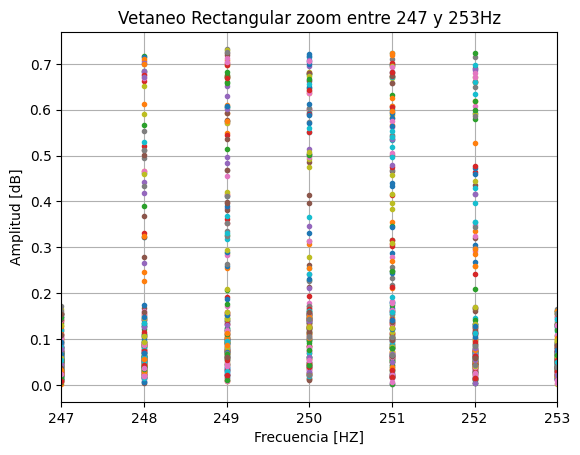

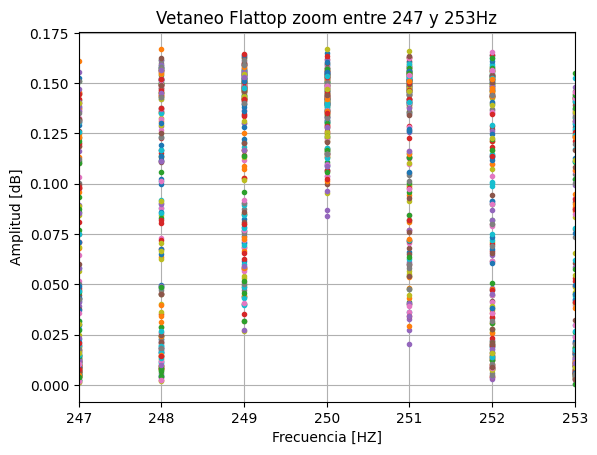

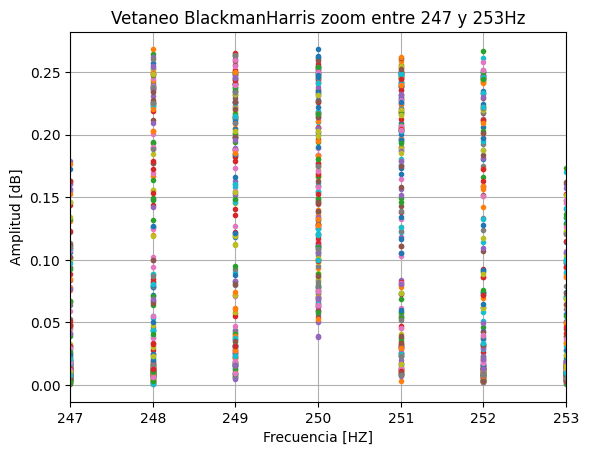

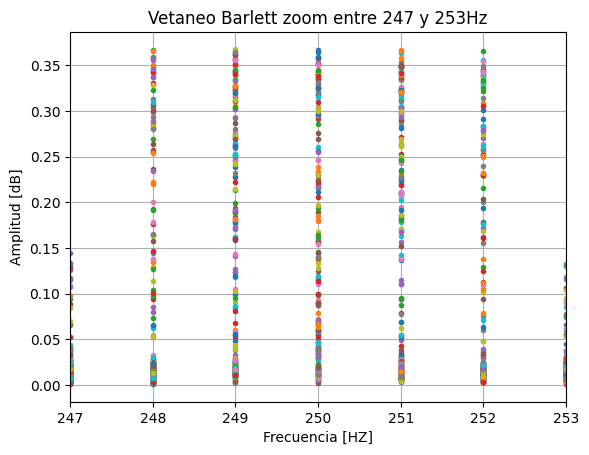

Ventana                     Sesgo     Varianza
----------------------------------------------
Rectangular              1.174897     0.050116
Flattop                  1.277029     0.000283
BlackmanHarris           1.258018     0.004431
Barlett                  1.270952     0.015525
**********************************************
**********************************************
Estimador de frecuencia
Ventana                     Sesgo     Varianza
----------------------------------------------
Rectangular              0.030000     1.649100
Flattop                  0.100000     1.810000
BlackmanHarris           0.050000     1.627500
Barlett                  0.030000     1.649100


In [14]:
##ventaneo
#para la rectangular no hace falta ventana explicita, ya que por el mero hecho de poner un N ya estamos ventaneando implicitamente
a1_flat_3 = seno_3*(sig.windows.flattop(N))
a1_black_3 = seno_3*(sig.windows.blackmanharris(N))
a1_bart_3=seno_3*(sig.windows.bartlett(N))

##transformada de Fourier
XX_rect3 = fft(seno_3,n=N,axis=1)* ts
abs_XX_rect3 = np.abs(XX_rect3)

XX_flat3 = fft(a1_flat_3,n=N,axis=1)*ts
abs_XX_flat3 = np.abs(XX_flat3)

XX_black3 = fft(a1_black_3,n=N,axis=1)*ts
abs_XX_black3 = np.abs(XX_black3)

XX_bart3 = fft(a1_bart_3,n=N,axis=1)*ts
abs_XX_bart3 = np.abs(XX_bart3)

#valores en logaritmo
abs_XX_rect3_db = 10*np.log10(abs_XX_rect3 + eps)
abs_XX_flat3_db = 10*np.log10(abs_XX_flat3 + eps)
abs_XX_black3_db = 10*np.log10(abs_XX_black3 + eps)
abs_XX_bart3_db = 10*np.log10(abs_XX_bart3 + eps)

plt.figure(1)            
plt.plot(eje_x, abs_XX_rect3[:, :N//2].T, marker='.', linestyle='None')
plt.title("Vetaneo Rectangular zoom entre 247 y 253Hz")
plt.xlabel("Frecuencia [HZ]")
plt.ylabel("Amplitud [dB]")
plt.xlim(247,253)  # zoom
plt.grid(True)
plt.show()

plt.figure(2)
plt.plot(eje_x, abs_XX_flat3[:, :N//2].T, marker='.', linestyle='None')
plt.title("Vetaneo Flattop zoom entre 247 y 253Hz")
plt.xlabel("Frecuencia [HZ]")
plt.ylabel("Amplitud [dB]")
plt.xlim(247,253)  # zoom
plt.grid(True)
plt.show()

plt.figure(3)
plt.plot(eje_x, abs_XX_black3[:, :N//2].T,marker='.', linestyle='None')
plt.title("Vetaneo BlackmanHarris zoom entre 247 y 253Hz")
plt.xlabel("Frecuencia [HZ]")
plt.ylabel("Amplitud [dB]")
plt.xlim(247,253)  # zoom
plt.grid(True)
plt.show()

plt.figure(4)
plt.plot(eje_x, abs_XX_bart3[:, :N//2].T,marker='.', linestyle='None')
plt.title("Vetaneo Barlett zoom entre 247 y 253Hz")
plt.xlabel("Frecuencia [HZ]")
plt.ylabel("Amplitud [dB]")
plt.xlim(247,253)  # zoom
plt.grid(True)
plt.show()

# # estimador amplitud
a1_rect_est3 = abs_XX_rect3[:,N//4]
a1_flat_est3 = abs_XX_flat3[:,N//4]
a1_black_est3 = abs_XX_black3[:,N//4]
a1_bart_est3 = abs_XX_bart3[:,N//4]

#sesgo de amplitud
sesgo_rect_3 = np.abs(np.mean(a1_rect_est3 - a0))
sesgo_flat_3 = np.abs(np.mean(a1_flat_est3 - a0))
sesgo_black_3 = np.abs(np.mean(a1_black_est3 - a0))
sesgo_bart_3 = np.abs(np.mean(a1_bart_est3 - a0))

#varianza de estimador de amplitud
var_rect_3 = np.var(a1_rect_est3)
var_flat_3 = np.var(a1_flat_est3)
var_black_3 = np.var(a1_black_est3)
var_bart_3 = np.var(a1_bart_est3)

# #estimador frecuencia
w1_rect3 = np.argmax(abs_XX_rect3[:, :N//2], axis=1)   # índice de la realización con mayor potencia
w1_flat3 = np.argmax(abs_XX_flat3[:, :N//2], axis=1)
w1_black3 = np.argmax(abs_XX_black3[:, :N//2], axis=1)
w1_bart3 = np.argmax(abs_XX_bart3[:, :N//2], axis=1)

sesgofr_rect_3 = np.abs(np.mean(w1_rect3 - w0 ))
sesgofr_flat_3 = np.abs(np.mean(w1_flat3 - w0))
sesgofr_black_3 = np.abs(np.mean(w1_black3 - w0))
sesgofr_bart_3 = np.abs(np.mean(w1_bart3 - w0))

varfr_rect_3 = np.var(w1_rect3)
varfr_flat_3 = np.var(w1_flat3)
varfr_black_3 = np.var(w1_black3)
varfr_bart_3 = np.var(w1_bart3)


print(f"{'Ventana':<20} {'Sesgo':>12} {'Varianza':>12}")
print("-" * 46)
print(f"{'Rectangular':<20} {sesgo_rect_3:>12.6f} {var_rect_3:>12.6f}")
print(f"{'Flattop':<20} {sesgo_flat_3:>12.6f} {var_flat_3:>12.6f}")
print(f"{'BlackmanHarris':<20} {sesgo_black_3:>12.6f} {var_black_3:>12.6f}")
print(f"{'Barlett':<20} {sesgo_bart_3:>12.6f} {var_bart_3:>12.6f}")

print("*" * 46)
print("*" * 46)

print('Estimador de frecuencia')
print(f"{'Ventana':<20} {'Sesgo':>12} {'Varianza':>12}")
print("-" * 46)
print(f"{'Rectangular':<20} {sesgofr_rect_3:>12.6f} {varfr_rect_3:>12.6f}")
print(f"{'Flattop':<20} {sesgofr_flat_3:>12.6f} {varfr_flat_3:>12.6f}")
print(f"{'BlackmanHarris':<20} {sesgofr_black_3:>12.6f} {varfr_black_3:>12.6f}")
print(f"{'Barlett':<20} {sesgofr_bart_3:>12.6f} {varfr_bart_3:>12.6f}")



Luego de ver ambas experiencias, podemos observar que el sesgo para el estimador de frecuencia son muy similares, lo que nos dice que no depende del tipo de ventana elegida.

## Histogramas de amplitud y frecuencias

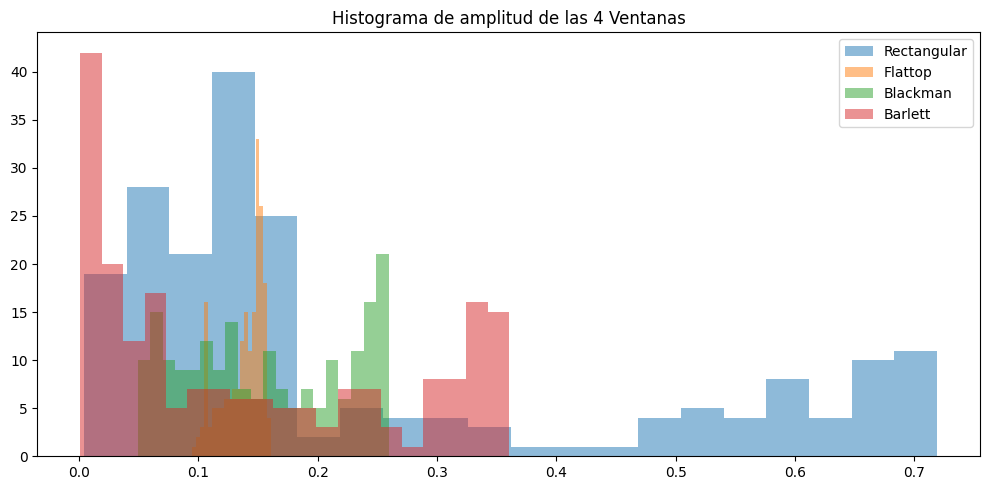

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(a1_rect_est10,  bins=20, alpha=0.5, label='Rectangular')
plt.hist(a1_flat_est10,  bins=20, alpha=0.5, label='Flattop')
plt.hist(a1_black_est10, bins=20, alpha=0.5, label='Blackman')
plt.hist(a1_bart_est10, bins=20, alpha=0.5, label='Barlett')
plt.title("Histograma de amplitud de las 4 Ventanas para 10dB")
plt.legend()
plt.tight_layout()
plt.show()

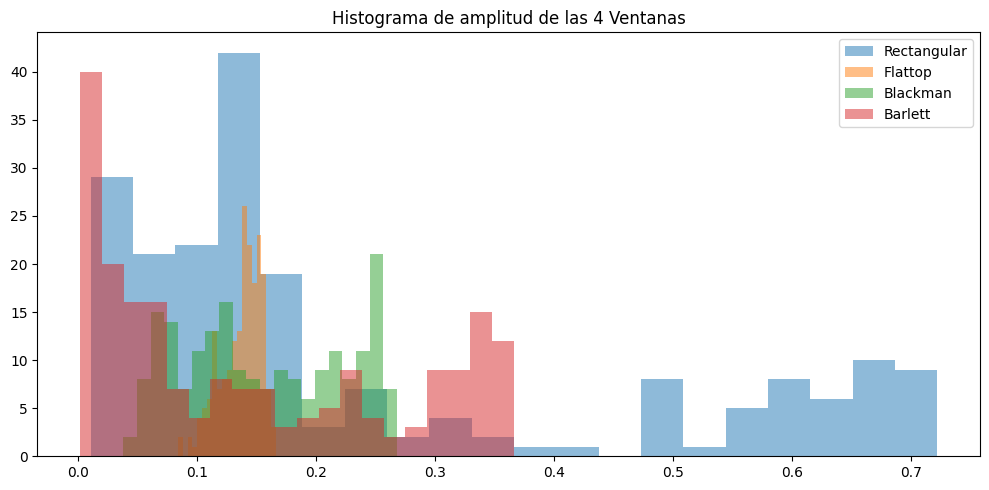

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(a1_rect_est3,  bins=20, alpha=0.5, label='Rectangular')
plt.hist(a1_flat_est3,  bins=20, alpha=0.5, label='Flattop')
plt.hist(a1_black_est3, bins=20, alpha=0.5, label='Blackman')
plt.hist(a1_bart_est3, bins=20, alpha=0.5, label='Barlett')
plt.title("Histograma de amplitud de las 4 Ventanas para 3dB")
plt.legend()
plt.tight_layout()
plt.show()

Como conclusion, vemos que claramente es conveniente ventanear a no hacer nada, es desparramo de una rectangular es notablemente visible que los demas metodos.

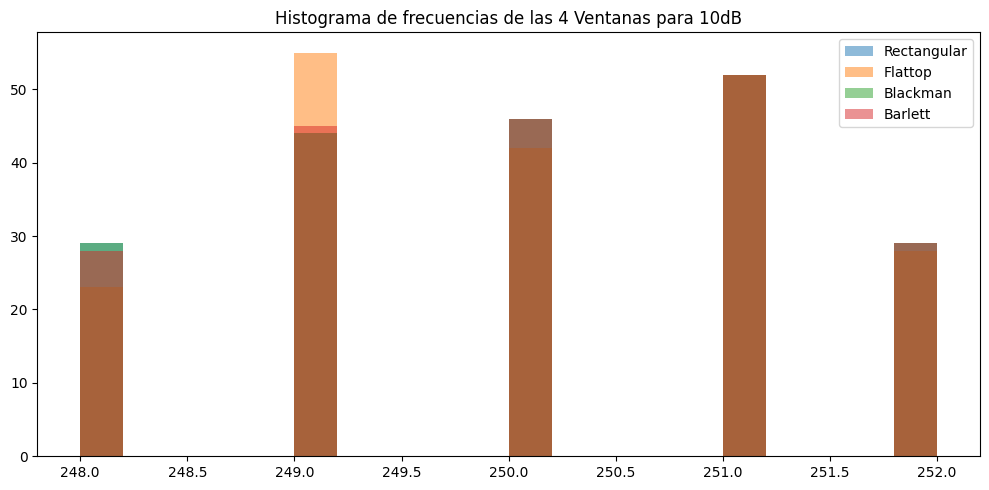

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(w1_rect10,  bins=20, alpha=0.5, label='Rectangular')
plt.hist(w1_flat10,  bins=20, alpha=0.5, label='Flattop')
plt.hist(w1_black10, bins=20, alpha=0.5, label='Blackman')
plt.hist(w1_bart10, bins=20, alpha=0.5, label='Barlett')
plt.title("Histograma de frecuencias de las 4 Ventanas para 10dB")
plt.legend()
plt.tight_layout()
plt.show()

No se ve claramente cada frecuencias pero si podemos apreciar la tendencia de la envolvente como una curva concava, esto se da porque en los extremos 248 y 252 hay menos probabilidades de pescar energia ahi debido a la resolucion espectral. En contra punto las Fr 249, 250 y 251 caben un bin completo.